In [1]:
# Setup: Run this cell first!

import torch
import torch.nn as nn
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

if torch.cuda.is_available():
    device = torch.device('cuda')
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU available: {gpu_name}")
    print(f"   Memory: {gpu_mem_gb:.1f} GB")
else:
    device = torch.device('cpu')
    gpu_mem_gb = 0
    print("No GPU detected. Calculator still works with manual GPU spec.")

print(f"\nPython {sys.version.split()[0]}")
print(f"PyTorch {torch.__version__}")

np.random.seed(42)
%matplotlib inline

GPU available: NVIDIA H100 80GB HBM3
   Memory: 85.3 GB

Python 3.12.10
PyTorch 2.7.0+cu128


/opt/pytorch/lib/python3.12/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


# Will It Fit? A GPU Memory Calculator -- Vizuara

## 1. Why Does This Matter?

Before you spend hours downloading a model, setting up your training script, and launching a job -- only to hit OOM 30 seconds in -- you should be able to answer one question:

**"Will this model fit on my GPU for training?"**

In this notebook, we build a complete memory calculator that answers this question for **any** model configuration. It combines everything from Notebooks 1 and 2:
- Weights (fp16 or fp32)
- Gradients (same size as weights)
- Optimizer states (Adam: master + m + v)
- Activations (batch size, sequence length, layers)

**What you will build:** An interactive "Will It Fit?" tool that predicts memory usage and recommends the maximum batch size for your GPU.

## 2. Building Intuition

Think of GPU memory like packing a suitcase for a trip:

- **Weights** = your clothes (fixed size, must bring them)
- **Gradients** = a duplicate set of clothes (same size as weights)
- **Optimizer states** = your toiletries, shoes, books (surprisingly large -- often bigger than the clothes!)
- **Activations** = souvenirs you pick up along the way (grows with trip length and how much you buy)

A good packer (engineer) checks if everything fits BEFORE trying to close the suitcase.

## 3. The Mathematics

The complete formula for training memory:

$$M_{\text{total}} = \underbrace{2\Psi}_{\text{weights}} + \underbrace{2\Psi}_{\text{gradients}} + \underbrace{12\Psi}_{\text{optimizer}} + \underbrace{L \cdot B \cdot S \cdot H \cdot 34}_{\text{activations}}$$

where $\Psi$ = number of parameters (mixed precision with Adam).

The first three terms are **fixed** for a given model. Only activations depend on batch size. So the maximum batch size is:

$$B_{\max} = \frac{M_{\text{GPU}} - 16\Psi}{L \cdot S \cdot H \cdot 34}$$

In practice, we also need ~10-15% overhead for PyTorch memory management, CUDA kernels, and fragmentation.

In [3]:
# The core memory calculator

def will_it_fit(
    num_params,
    num_layers,
    hidden_dim,
    num_heads,
    batch_size,
    seq_len,
    gpu_memory_gb,
    precision="mixed",
    optimizer="adam",
    activation_checkpointing=False,
    overhead_pct=0.12,
):
    """Comprehensive GPU memory calculator.

    Args:
        num_params: Total parameters (e.g., 7e9)
        num_layers: Number of transformer layers
        hidden_dim: Hidden dimension
        num_heads: Number of attention heads
        batch_size: Training batch size
        seq_len: Sequence length
        gpu_memory_gb: Available GPU memory in GB
        precision: 'fp32', 'fp16', or 'mixed'
        optimizer: 'adam', 'sgd', or 'adamw'
        activation_checkpointing: If True, assume sqrt(L) activation memory
        overhead_pct: PyTorch/CUDA overhead fraction (default 12%)

    Returns:
        Dictionary with detailed memory breakdown and fit verdict.
    """
    to_gb = lambda b: b / (1024**3)

    # --- Weights ---
    if precision == "fp32":
        weight_gb = to_gb(num_params * 4)
    else:
        weight_gb = to_gb(num_params * 2)

    # --- Gradients ---
    grad_gb = weight_gb  # same size as weights

    # --- Optimizer ---
    if optimizer in ["adam", "adamw"]:
        if precision == "mixed":
            opt_gb = to_gb(num_params * 12)  # master + m + v
        elif precision == "fp32":
            opt_gb = to_gb(num_params * 8)   # m + v (weights already fp32)
        else:
            opt_gb = to_gb(num_params * 8)   # m + v
    elif optimizer == "sgd":
        opt_gb = to_gb(num_params * 4)  # just momentum buffer
    else:
        opt_gb = to_gb(num_params * 8)  # default: assume 2 states

    # --- Activations ---
    bytes_per_activation = 34 + 5 * (num_heads * seq_len / hidden_dim)
    act_bytes = num_layers * batch_size * seq_len * hidden_dim * bytes_per_activation

    if activation_checkpointing:
        # Checkpointing saves activations only at sqrt(L) layers
        act_bytes = act_bytes * (num_layers ** 0.5) / num_layers

    act_gb = to_gb(act_bytes)

    # --- Totals ---
    model_gb = weight_gb + grad_gb + opt_gb  # fixed cost
    total_gb = model_gb + act_gb
    usable_gb = gpu_memory_gb * (1 - overhead_pct)
    overhead_gb = gpu_memory_gb * overhead_pct

    fits = total_gb <= usable_gb

    # --- Max batch size ---
    act_per_sample = num_layers * seq_len * hidden_dim * bytes_per_activation
    if activation_checkpointing:
        act_per_sample = act_per_sample * (num_layers ** 0.5) / num_layers
    remaining_bytes = (usable_gb - model_gb) * (1024**3)
    max_batch_size = max(0, int(remaining_bytes / act_per_sample))

    return {
        "weights_gb": weight_gb,
        "gradients_gb": grad_gb,
        "optimizer_gb": opt_gb,
        "activations_gb": act_gb,
        "model_fixed_gb": model_gb,
        "total_gb": total_gb,
        "overhead_gb": overhead_gb,
        "usable_gb": usable_gb,
        "gpu_memory_gb": gpu_memory_gb,
        "fits": fits,
        "max_batch_size": max_batch_size,
        "utilization_pct": (total_gb / usable_gb) * 100 if usable_gb > 0 else 999,
    }

print("will_it_fit() calculator ready!")

will_it_fit() calculator ready!


## 4. Let's Build It -- Component by Component

### The Pretty Printer

In [4]:
def print_report(result, model_name="Model", config_str=""):
    """Print a formatted memory report."""
    r = result

    verdict = "FITS" if r['fits'] else "DOES NOT FIT"
    verdict_emoji = "[OK]" if r['fits'] else "[X]"

    print(f"\n{'='*65}")
    print(f"  WILL IT FIT?  {model_name}")
    if config_str:
        print(f"  {config_str}")
    print(f"{'='*65}")
    print(f"")
    print(f"  {'Component':<30} {'Memory':>10} {'Share':>8}")
    print(f"  {'-'*48}")
    print(f"  {'Weights':<30} {r['weights_gb']:>8.2f} GB {r['weights_gb']/r['total_gb']*100:>6.1f}%")
    print(f"  {'Gradients':<30} {r['gradients_gb']:>8.2f} GB {r['gradients_gb']/r['total_gb']*100:>6.1f}%")
    print(f"  {'Optimizer States':<30} {r['optimizer_gb']:>8.2f} GB {r['optimizer_gb']/r['total_gb']*100:>6.1f}%")
    print(f"  {'Activations':<30} {r['activations_gb']:>8.2f} GB {r['activations_gb']/r['total_gb']*100:>6.1f}%")
    print(f"  {'-'*48}")
    print(f"  {'TOTAL REQUIRED':<30} {r['total_gb']:>8.2f} GB")
    print(f"  {'GPU Available':<30} {r['gpu_memory_gb']:>8.2f} GB")
    print(f"  {'Overhead (~12%)':<30} {r['overhead_gb']:>8.2f} GB")
    print(f"  {'Usable':<30} {r['usable_gb']:>8.2f} GB")
    print(f"")
    print(f"  Verdict: {verdict_emoji} {verdict}")
    print(f"  GPU utilization: {r['utilization_pct']:.1f}%")
    print(f"  Max batch size: {r['max_batch_size']}")
    print(f"{'='*65}")

    if not r['fits']:
        excess = r['total_gb'] - r['usable_gb']
        print(f"\n  Exceeds GPU by {excess:.1f} GB. Suggestions:")
        print(f"    1. Reduce batch size (current activations: {r['activations_gb']:.1f} GB)")
        if r['max_batch_size'] > 0:
            print(f"    2. Max batch size that fits: {r['max_batch_size']}")
        else:
            print(f"    2. Model params alone ({r['model_fixed_gb']:.1f} GB) exceed GPU!")
            print(f"       -> Need model parallelism or ZeRO")
        print(f"    3. Use activation checkpointing to reduce activation memory")
        print(f"    4. Use ZeRO to shard optimizer states across GPUs")

print("Report printer ready.")

Report printer ready.


In [5]:
# Pre-defined model configurations

MODEL_CONFIGS = {
    "GPT-2 (124M)": {
        "num_params": 124e6, "num_layers": 12,
        "hidden_dim": 768, "num_heads": 12,
    },
    "GPT-2 XL (1.5B)": {
        "num_params": 1.5e9, "num_layers": 48,
        "hidden_dim": 1600, "num_heads": 25,
    },
    "LLaMA-7B": {
        "num_params": 7e9, "num_layers": 32,
        "hidden_dim": 4096, "num_heads": 32,
    },
    "LLaMA-13B": {
        "num_params": 13e9, "num_layers": 40,
        "hidden_dim": 5120, "num_heads": 40,
    },
    "LLaMA-70B": {
        "num_params": 70e9, "num_layers": 80,
        "hidden_dim": 8192, "num_heads": 64,
    },
    "Mixtral-8x7B (active)": {
        "num_params": 12.9e9, "num_layers": 32,
        "hidden_dim": 4096, "num_heads": 32,
    },
}

GPU_CONFIGS = {
    "T4 (16 GB)": 16,
    "RTX 3090 (24 GB)": 24,
    "RTX 4090 (24 GB)": 24,
    "A100 (40 GB)": 40,
    "A100 (80 GB)": 80,
    "H100 (80 GB)": 80,
}

print("Available model configs:", list(MODEL_CONFIGS.keys()))
print("Available GPU configs: ", list(GPU_CONFIGS.keys()))

Available model configs: ['GPT-2 (124M)', 'GPT-2 XL (1.5B)', 'LLaMA-7B', 'LLaMA-13B', 'LLaMA-70B', 'Mixtral-8x7B (active)']
Available GPU configs:  ['T4 (16 GB)', 'RTX 3090 (24 GB)', 'RTX 4090 (24 GB)', 'A100 (40 GB)', 'A100 (80 GB)', 'H100 (80 GB)']


In [6]:
# Example 1: GPT-2 on a T4 (Colab free tier)

config = MODEL_CONFIGS["GPT-2 (124M)"]
result = will_it_fit(
    **config,
    batch_size=8,
    seq_len=1024,
    gpu_memory_gb=16,
    precision="mixed",
)

print_report(result, "GPT-2 (124M)", "B=8, S=1024, Mixed Precision, T4 16GB")


  WILL IT FIT?  GPT-2 (124M)
  B=8, S=1024, Mixed Precision, T4 16GB

  Component                          Memory    Share
  ------------------------------------------------
  Weights                            0.23 GB    2.3%
  Gradients                          0.23 GB    2.3%
  Optimizer States                   1.39 GB   14.1%
  Activations                        8.02 GB   81.3%
  ------------------------------------------------
  TOTAL REQUIRED                     9.86 GB
  GPU Available                     16.00 GB
  Overhead (~12%)                    1.92 GB
  Usable                            14.08 GB

  Verdict: [OK] FITS
  GPU utilization: 70.1%
  Max batch size: 12


In [7]:
# Example 2: LLaMA-7B on A100 80GB

config = MODEL_CONFIGS["LLaMA-7B"]
result = will_it_fit(
    **config,
    batch_size=4,
    seq_len=2048,
    gpu_memory_gb=80,
    precision="mixed",
)

print_report(result, "LLaMA-7B", "B=4, S=2048, Mixed Precision, A100 80GB")


  WILL IT FIT?  LLaMA-7B
  B=4, S=2048, Mixed Precision, A100 80GB

  Component                          Memory    Share
  ------------------------------------------------
  Weights                           13.04 GB    6.0%
  Gradients                         13.04 GB    6.0%
  Optimizer States                  78.23 GB   35.8%
  Activations                      114.00 GB   52.2%
  ------------------------------------------------
  TOTAL REQUIRED                   218.31 GB
  GPU Available                     80.00 GB
  Overhead (~12%)                    9.60 GB
  Usable                            70.40 GB

  Verdict: [X] DOES NOT FIT
  GPU utilization: 310.1%
  Max batch size: 0

  Exceeds GPU by 147.9 GB. Suggestions:
    1. Reduce batch size (current activations: 114.0 GB)
    2. Model params alone (104.3 GB) exceed GPU!
       -> Need model parallelism or ZeRO
    3. Use activation checkpointing to reduce activation memory
    4. Use ZeRO to shard optimizer states across GPUs


In [8]:
# Example 3: The OOM scenario from the article!
# LLaMA-7B, batch_size=4, on a 24GB GPU

config = MODEL_CONFIGS["LLaMA-7B"]
result = will_it_fit(
    **config,
    batch_size=4,
    seq_len=2048,
    gpu_memory_gb=24,
    precision="mixed",
)

print_report(result, "LLaMA-7B", "B=4, S=2048, Mixed Precision, RTX 3090 24GB")

print("\nThis is exactly the OOM scenario from the article!")
print("The model params alone (weights + grads + optimizer) exceed 24 GB.")


  WILL IT FIT?  LLaMA-7B
  B=4, S=2048, Mixed Precision, RTX 3090 24GB

  Component                          Memory    Share
  ------------------------------------------------
  Weights                           13.04 GB    6.0%
  Gradients                         13.04 GB    6.0%
  Optimizer States                  78.23 GB   35.8%
  Activations                      114.00 GB   52.2%
  ------------------------------------------------
  TOTAL REQUIRED                   218.31 GB
  GPU Available                     24.00 GB
  Overhead (~12%)                    2.88 GB
  Usable                            21.12 GB

  Verdict: [X] DOES NOT FIT
  GPU utilization: 1033.7%
  Max batch size: 0

  Exceeds GPU by 197.2 GB. Suggestions:
    1. Reduce batch size (current activations: 114.0 GB)
    2. Model params alone (104.3 GB) exceed GPU!
       -> Need model parallelism or ZeRO
    3. Use activation checkpointing to reduce activation memory
    4. Use ZeRO to shard optimizer states across GPU

### The Visual Report

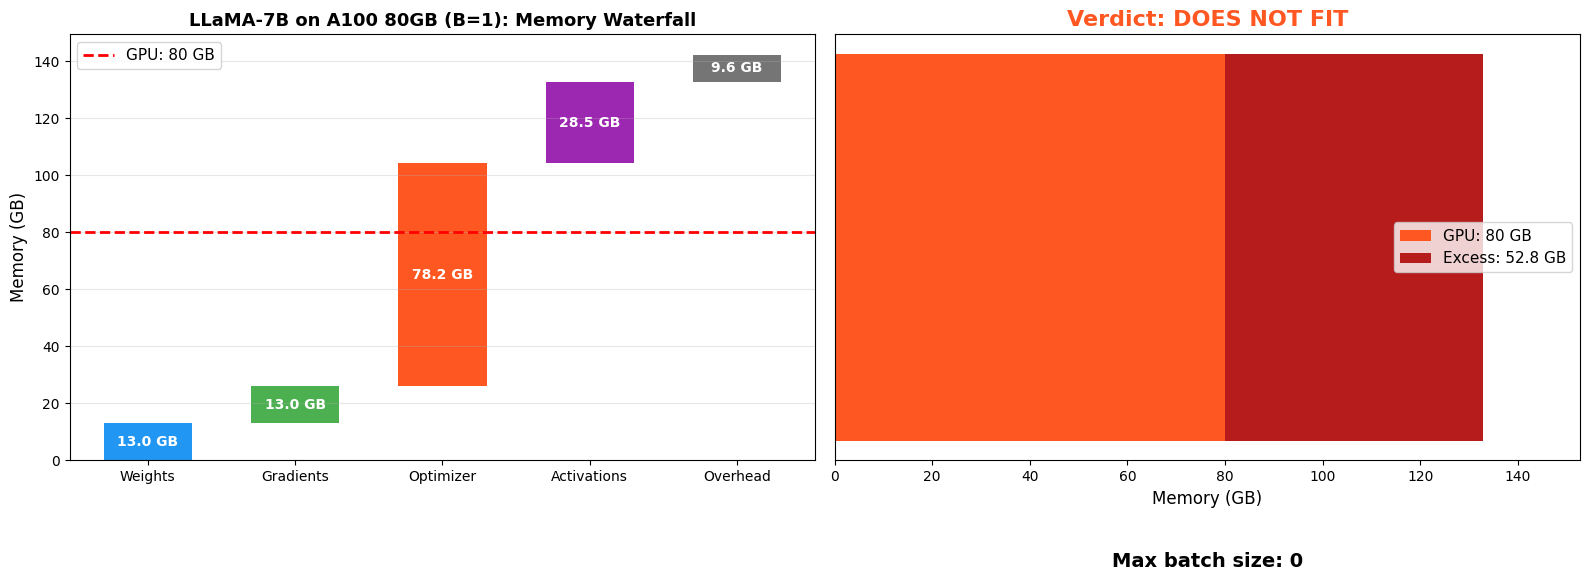

In [9]:
def visual_report(result, model_name="Model"):
    """Create a visual memory report."""
    r = result

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # --- Panel 1: Memory waterfall ---
    components = [
        ('Weights', r['weights_gb'], '#2196F3'),
        ('Gradients', r['gradients_gb'], '#4CAF50'),
        ('Optimizer', r['optimizer_gb'], '#FF5722'),
        ('Activations', r['activations_gb'], '#9C27B0'),
        ('Overhead', r['overhead_gb'], '#757575'),
    ]

    names = [c[0] for c in components]
    values = [c[1] for c in components]
    colors = [c[2] for c in components]
    cumulative = np.cumsum([0] + values[:-1])

    bars = axes[0].bar(names, values, bottom=cumulative, color=colors, width=0.6)

    # GPU limit line
    axes[0].axhline(y=r['gpu_memory_gb'], color='red', linestyle='--',
                     linewidth=2, label=f"GPU: {r['gpu_memory_gb']:.0f} GB")

    # Annotate each bar with size
    for bar, val, cum in zip(bars, values, cumulative):
        if val > 0.5:  # Only label if visible
            axes[0].text(bar.get_x() + bar.get_width()/2, cum + val/2,
                        f'{val:.1f} GB', ha='center', va='center',
                        fontsize=10, color='white', fontweight='bold')

    axes[0].set_ylabel('Memory (GB)', fontsize=12)
    axes[0].set_title(f'{model_name}: Memory Waterfall', fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(axis='y', alpha=0.3)

    # --- Panel 2: Gauge-style utilization ---
    # Stacked horizontal bar
    used = r['total_gb']
    available = r['gpu_memory_gb']
    remaining = max(0, available - used)
    excess = max(0, used - available)

    if r['fits']:
        axes[1].barh(0, used, color='#4CAF50', height=0.5, label=f'Used: {used:.1f} GB')
        axes[1].barh(0, remaining, left=used, color='#E0E0E0', height=0.5, label=f'Free: {remaining:.1f} GB')
    else:
        axes[1].barh(0, available, color='#FF5722', height=0.5, label=f'GPU: {available:.0f} GB')
        axes[1].barh(0, excess, left=available, color='#B71C1C', height=0.5, label=f'Excess: {excess:.1f} GB')

    axes[1].set_xlim(0, max(used, available) * 1.15)
    axes[1].set_yticks([])
    axes[1].set_xlabel('Memory (GB)', fontsize=12)

    verdict = "FITS!" if r['fits'] else "DOES NOT FIT"
    color = '#4CAF50' if r['fits'] else '#FF5722'
    axes[1].set_title(f'Verdict: {verdict}', fontsize=16, fontweight='bold', color=color)
    axes[1].legend(fontsize=11, loc='center right')

    # Add max batch size annotation
    axes[1].text(0.5, -0.25, f'Max batch size: {r["max_batch_size"]}',
                transform=axes[1].transAxes, fontsize=14, ha='center',
                fontweight='bold')

    plt.tight_layout()
    plt.show()

# Show visual report for LLaMA-7B on A100
config = MODEL_CONFIGS["LLaMA-7B"]
result = will_it_fit(**config, batch_size=1, seq_len=2048, gpu_memory_gb=80, precision="mixed")
visual_report(result, "LLaMA-7B on A100 80GB (B=1)")

### The Compatibility Matrix

Let us check which models fit on which GPUs.

In [10]:
# Build a compatibility matrix: which models fit on which GPUs?

print("Compatibility Matrix: Model x GPU (mixed precision, B=1, S=2048)")
print("Max batch size shown. '-' means model params alone exceed GPU.")
print("=" * 90)

gpu_names = list(GPU_CONFIGS.keys())
header = f"{'Model':<25}" + "".join(f"{g:<12}" for g in gpu_names)
print(header)
print("-" * 90)

for model_name, config in MODEL_CONFIGS.items():
    row = f"{model_name:<25}"
    for gpu_name, gpu_mem in GPU_CONFIGS.items():
        result = will_it_fit(
            **config,
            batch_size=1,
            seq_len=2048,
            gpu_memory_gb=gpu_mem,
            precision="mixed",
        )
        if result['max_batch_size'] > 0:
            row += f"B<={result['max_batch_size']:<8}"
        else:
            row += f"{'  -':<12}"
    print(row)

print("\nNote: These are theoretical maximums. Actual batch sizes may be slightly lower")
print("due to memory fragmentation and PyTorch internals.")

Compatibility Matrix: Model x GPU (mixed precision, B=1, S=2048)
Max batch size shown. '-' means model params alone exceed GPU.
Model                    T4 (16 GB)  RTX 3090 (24 GB)RTX 4090 (24 GB)A100 (40 GB)A100 (80 GB)H100 (80 GB)
------------------------------------------------------------------------------------------
GPT-2 (124M)             B<=3       B<=5       B<=5       B<=9       B<=20      B<=20      
GPT-2 XL (1.5B)            -           -           -           -         B<=1       B<=1       
LLaMA-7B                   -           -           -           -           -           -         
LLaMA-13B                  -           -           -           -           -           -         
LLaMA-70B                  -           -           -           -           -           -         
Mixtral-8x7B (active)      -           -           -           -           -           -         

Note: These are theoretical maximums. Actual batch sizes may be slightly lower
due to memory f

## 5. Your Turn -- TODO Exercises

### TODO 1: Your GPU, Your Model

Use the calculator to check if you can train GPT-2 (124M) on your current Colab GPU. Find the maximum batch size with sequence length 512.

In [12]:
if torch.cuda.is_available():
    my_gpu_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    my_gpu_name = torch.cuda.get_device_name(0)
else:
    my_gpu_gb = 16
    my_gpu_name = "T4 (assumed)"

print(f"Your GPU: {my_gpu_name} ({my_gpu_gb:.1f} GB)")

config = MODEL_CONFIGS["GPT-2 (124M)"]

print(f"\nGPT-2 (124M), seq_len=512, mixed precision on {my_gpu_name}:")
print(f"{'Batch Size':<12} {'Total (GB)':<12} {'Fits?':<8}")
print("-" * 35)

max_bs = 0
for bs in [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]:
    result = will_it_fit(**config, batch_size=bs, seq_len=512,
                        gpu_memory_gb=my_gpu_gb, precision="mixed")
    fits = "YES" if result['fits'] else "NO"
    print(f"{bs:<12} {result['total_gb']:<12.2f} {fits:<8}")
    if result['fits']:
        max_bs = bs

print(f"\nMax batch size that fits: {max_bs}")

Your GPU: NVIDIA H100 80GB HBM3 (85.3 GB)

GPT-2 (124M), seq_len=512, mixed precision on NVIDIA H100 80GB HBM3:
Batch Size   Total (GB)   Fits?   
-----------------------------------
1            2.17         YES     
2            2.50         YES     
4            3.15         YES     
8            4.45         YES     
16           7.05         YES     
32           12.25        YES     
64           22.66        YES     
128          43.47        YES     
256          85.10        NO      
512          168.35       NO      
1024         334.85       NO      

Max batch size that fits: 128


### TODO 2: Activation Checkpointing Impact

Activation checkpointing (gradient checkpointing) saves only $\sqrt{L}$ layers of activations instead of all $L$, recomputing the rest during the backward pass.

Use the `activation_checkpointing=True` parameter in `will_it_fit()` to see how much it helps for LLaMA-7B. How much larger can the batch size be?

In [13]:
config = MODEL_CONFIGS["LLaMA-7B"]

# Without activation checkpointing
result_no_ckpt = will_it_fit(**config, batch_size=1, seq_len=2048,
                            gpu_memory_gb=80, precision="mixed",
                            activation_checkpointing=False)

# With activation checkpointing
result_ckpt = will_it_fit(**config, batch_size=1, seq_len=2048,
                            gpu_memory_gb=80, precision="mixed",
                            activation_checkpointing=True)

print("LLaMA-7B on A100 80GB, S=2048, Mixed Precision")
print("=" * 60)
print(f"{'Metric':<30} {'No Ckpt':<15} {'With Ckpt':<15}")
print("-" * 60)
print(f"{'Activation memory':<30} {result_no_ckpt['activations_gb']:.2f} GB{'':<7} {result_ckpt['activations_gb']:.2f} GB")
print(f"{'Total memory':<30} {result_no_ckpt['total_gb']:.2f} GB{'':<6} {result_ckpt['total_gb']:.2f} GB")
print(f"{'Fits?':<30} {'Yes' if result_no_ckpt['fits'] else 'No':<15} {'Yes' if result_ckpt['fits'] else 'No':<15}")
print(f"{'Max batch size':<30} {result_no_ckpt['max_batch_size']:<15} {result_ckpt['max_batch_size']:<15}")

print(f"\nActivation memory reduction: {result_no_ckpt['activations_gb']/result_ckpt['activations_gb']:.1f}x")
print(f"Batch size increase: {result_ckpt['max_batch_size']/max(result_no_ckpt['max_batch_size'],1):.1f}x")
print(f"\nTradeoff: ~33% more compute (recomputing activations during backward)")

LLaMA-7B on A100 80GB, S=2048, Mixed Precision
Metric                         No Ckpt         With Ckpt      
------------------------------------------------------------
Activation memory              28.50 GB        5.04 GB
Total memory                   132.81 GB       109.35 GB
Fits?                          No              No             
Max batch size                 0               0              

Activation memory reduction: 5.7x
Batch size increase: 0.0x

Tradeoff: ~33% more compute (recomputing activations during backward)


### TODO 3: Custom Model Configuration

Design a transformer model that fits on a T4 (16 GB) GPU for training with batch size 4 and sequence length 512. Find the maximum number of parameters you can use.

**Constraints:**
- Hidden dim must be divisible by num_heads
- Use mixed precision
- Must fit with B=4, S=512

In [14]:
def estimate_params(num_layers, hidden_dim, vocab_size=32000):
    """Rough estimate of transformer parameter count."""
    per_layer = 12 * hidden_dim**2 + 13 * hidden_dim
    embeddings = vocab_size * hidden_dim
    return num_layers * per_layer + embeddings

print("Searching for largest model that fits on T4 (16 GB), B=4, S=512, mixed precision:")
print(f"{'Layers':<8} {'Hidden':<8} {'Heads':<8} {'Params':<12} {'Total GB':<12} {'Fits?'}")
print("-" * 60)

best_config = None
best_params = 0

for H in [512, 768, 1024, 1536, 2048]:
    for L in [6, 12, 18, 24]:
        A = H // 64
        P = estimate_params(L, H)
        result = will_it_fit(P, L, H, A, batch_size=4, seq_len=512,
                            gpu_memory_gb=16, precision='mixed')
        fits = "YES" if result['fits'] else "no"

        if result['fits']:
            print(f"{L:<8} {H:<8} {A:<8} {P/1e6:<12.0f}M {result['total_gb']:<12.2f} {fits}")
            if P > best_params:
                best_params = P
                best_config = (L, H, A, P, result['total_gb'])

print(f"\n{'='*60}")
if best_config:
    L, H, A, P, mem = best_config
    print(f"BEST: L={L}, H={H}, A={A}")
    print(f"  Parameters: {P/1e6:.0f}M")
    print(f"  Memory: {mem:.2f} GB (out of 14.1 GB usable)")
else:
    print("No configuration fits!")

Searching for largest model that fits on T4 (16 GB), B=4, S=512, mixed precision:
Layers   Hidden   Heads    Params       Total GB     Fits?
------------------------------------------------------------
6        512      8        35          M 0.96         YES
12       512      8        54          M 1.68         YES
18       512      8        73          M 2.39         YES
24       512      8        92          M 3.11         YES
6        768      12       67          M 1.65         YES
12       768      12       110         M 2.93         YES
18       768      12       152         M 4.22         YES
24       768      12       195         M 5.50         YES
6        1024     16       108         M 2.48         YES
12       1024     16       184         M 4.48         YES
18       1024     16       260         M 6.47         YES
24       1024     16       335         M 8.46         YES
6        1536     24       219         M 4.57         YES
12       1536     24       389         M 8.4

## 6. Putting It All Together

Let us create the ultimate visualization: a heatmap showing the maximum batch size for every model x GPU combination.

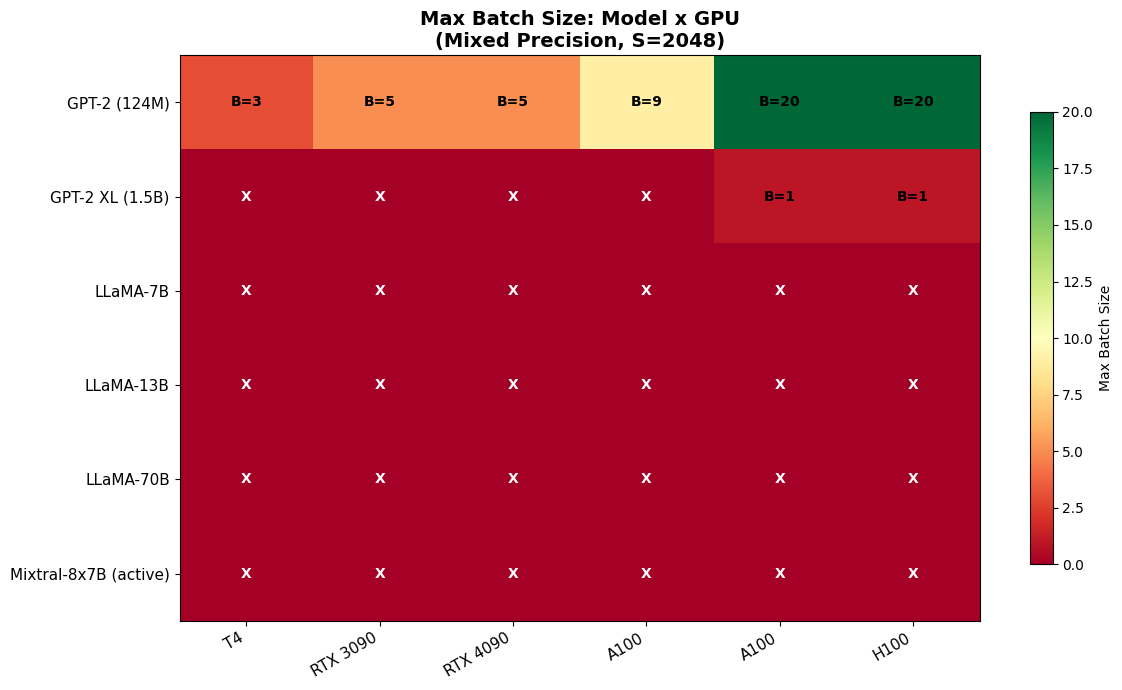

Red/X = does not fit even with B=1 (need multi-GPU or ZeRO)
Green = fits comfortably with larger batch sizes


In [15]:
# Heatmap: max batch size for each model x GPU combination

model_names = list(MODEL_CONFIGS.keys())
gpu_names_short = [g.split('(')[0].strip() for g in GPU_CONFIGS.keys()]
gpu_mems = list(GPU_CONFIGS.values())

# Build the matrix
matrix = np.zeros((len(model_names), len(gpu_mems)))

for i, (model_name, config) in enumerate(MODEL_CONFIGS.items()):
    for j, gpu_mem in enumerate(gpu_mems):
        result = will_it_fit(
            **config,
            batch_size=1,
            seq_len=2048,
            gpu_memory_gb=gpu_mem,
            precision="mixed",
        )
        matrix[i, j] = result['max_batch_size']

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 7))

# Use log scale colors for better visibility
im = ax.imshow(matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=max(matrix.flatten().max(), 1))

ax.set_xticks(range(len(gpu_names_short)))
ax.set_xticklabels(gpu_names_short, rotation=30, ha='right', fontsize=11)
ax.set_yticks(range(len(model_names)))
ax.set_yticklabels(model_names, fontsize=11)

# Add text annotations
for i in range(len(model_names)):
    for j in range(len(gpu_mems)):
        val = int(matrix[i, j])
        text = f"B={val}" if val > 0 else "X"
        color = 'black' if val > 5 else ('white' if val == 0 else 'black')
        ax.text(j, i, text, ha='center', va='center', fontsize=10,
                fontweight='bold', color=color)

ax.set_title('Max Batch Size: Model x GPU\n(Mixed Precision, S=2048)', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax, label='Max Batch Size', shrink=0.8)

plt.tight_layout()
plt.show()

print("Red/X = does not fit even with B=1 (need multi-GPU or ZeRO)")
print("Green = fits comfortably with larger batch sizes")

## 7. Training and Results

Let us verify the calculator against actual GPU memory usage.

In [16]:
# Validate the calculator against real GPU measurements

if torch.cuda.is_available():
    from torch.cuda.amp import autocast, GradScaler

    class TestTransformer(nn.Module):
        def __init__(self, vocab_size=10000, hidden_dim=512, num_layers=6, num_heads=8):
            super().__init__()
            self.embed = nn.Embedding(vocab_size, hidden_dim)
            self.layers = nn.ModuleList([
                nn.TransformerEncoderLayer(
                    d_model=hidden_dim, nhead=num_heads,
                    dim_feedforward=hidden_dim*4, batch_first=True
                )
                for _ in range(num_layers)
            ])
            self.head = nn.Linear(hidden_dim, vocab_size)

        def forward(self, x):
            x = self.embed(x)
            for layer in self.layers:
                x = layer(x)
            return self.head(x)

    # Test configurations
    test_configs = [
        (4, 128, "small batch"),
        (8, 128, "medium batch"),
        (16, 128, "large batch"),
        (4, 256, "long sequence"),
    ]

    hidden_dim = 512
    num_layers = 6
    num_heads = 8
    vocab_size = 10000

    print(f"Validation: TestTransformer (H={hidden_dim}, L={num_layers}, A={num_heads})")
    print(f"{'Config':<25} {'Predicted (GB)':<18} {'Measured (GB)':<18} {'Error'}")
    print("-" * 75)

    for bs, sl, desc in test_configs:
        # Prediction
        num_params = sum(p.numel() for p in TestTransformer(vocab_size, hidden_dim, num_layers, num_heads).parameters())
        pred = will_it_fit(
            num_params, num_layers, hidden_dim, num_heads,
            bs, sl, gpu_memory_gb=80, precision="mixed"
        )

        # Actual measurement
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

        model = TestTransformer(vocab_size, hidden_dim, num_layers, num_heads).to(device)
        opt = torch.optim.Adam(model.parameters(), lr=1e-4)
        scaler = GradScaler()

        x = torch.randint(0, vocab_size, (bs, sl)).to(device)
        t = torch.randint(0, vocab_size, (bs, sl)).to(device)

        opt.zero_grad()
        with autocast(dtype=torch.float16):
            out = model(x)
            loss = nn.functional.cross_entropy(out.view(-1, vocab_size), t.view(-1))
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()

        measured_gb = torch.cuda.max_memory_allocated() / 1e9

        del model, opt, scaler, x, t
        torch.cuda.empty_cache()

        error_pct = abs(pred['total_gb'] - measured_gb) / measured_gb * 100
        print(f"B={bs}, S={sl} ({desc}){'':<8} {pred['total_gb']:<18.3f} {measured_gb:<18.3f} {error_pct:.1f}%")

    print("\nNote: Some error is expected due to PyTorch overhead, temporary buffers, etc.")
else:
    print("GPU required for validation. The theoretical calculator is still useful without a GPU.")

Validation: TestTransformer (H=512, L=6, A=8)
Config                    Predicted (GB)     Measured (GB)      Error
---------------------------------------------------------------------------


/opt/dlami/nvme/tmp/ipykernel_3803714/3085072146.py:56: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/opt/dlami/nvme/tmp/ipykernel_3803714/3085072146.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.float16):


B=4, S=128 (small batch)         0.499              0.673              25.8%
B=8, S=128 (medium batch)         0.563              0.696              19.0%
B=16, S=128 (large batch)         0.692              0.908              23.8%
B=4, S=256 (long sequence)         0.593              0.698              15.0%

Note: Some error is expected due to PyTorch overhead, temporary buffers, etc.


## 8. Final Output

In [17]:
print("=" * 65)
print("SUMMARY: Will It Fit? GPU Memory Calculator")
print("=" * 65)
print()
print("The Complete Formula (mixed precision + Adam):")
print("  M_total = 16P + L * B * S * H * 34 bytes")
print("          = (fixed model cost) + (variable activation cost)")
print()
print("Maximum Batch Size:")
print("  B_max = (GPU_mem * 0.88 - 16P) / (L * S * H * 34)")
print()
print("Quick Reference Card:")
print("-" * 65)
print(f"  {'Model':<20} {'Fixed Cost':<15} {'Act/sample':<15} {'Min GPU'}")
print("-" * 65)
for name, config in MODEL_CONFIGS.items():
    r = will_it_fit(**config, batch_size=1, seq_len=2048, gpu_memory_gb=1000, precision='mixed')
    fixed = r['model_fixed_gb']
    act_1 = r['activations_gb']
    min_gpu = fixed + act_1 + fixed * 0.12
    print(f"  {name:<20} {fixed:>8.1f} GB    {act_1:>8.1f} GB    {min_gpu:>6.0f} GB")
print()
print("When It Does Not Fit:")
print("  1. Reduce batch size (cheapest fix)")
print("  2. Activation checkpointing (trades compute for memory)")
print("  3. ZeRO-1/2/3 (shard optimizer/gradients/weights across GPUs)")
print("  4. Tensor parallelism (split model across GPUs)")
print("  5. Pipeline parallelism (split layers across GPUs)")

SUMMARY: Will It Fit? GPU Memory Calculator

The Complete Formula (mixed precision + Adam):
  M_total = 16P + L * B * S * H * 34 bytes
          = (fixed model cost) + (variable activation cost)

Maximum Batch Size:
  B_max = (GPU_mem * 0.88 - 16P) / (L * S * H * 34)

Quick Reference Card:
-----------------------------------------------------------------
  Model                Fixed Cost      Act/sample      Min GPU
-----------------------------------------------------------------
  GPT-2 (124M)              1.8 GB         3.4 GB         5 GB
  GPT-2 XL (1.5B)          22.4 GB        28.4 GB        53 GB
  LLaMA-7B                104.3 GB        28.5 GB       145 GB
  LLaMA-13B               193.7 GB        44.5 GB       261 GB
  LLaMA-70B              1043.1 GB       142.5 GB      1311 GB
  Mixtral-8x7B (active)    192.2 GB        28.5 GB       244 GB

When It Does Not Fit:
  1. Reduce batch size (cheapest fix)
  2. Activation checkpointing (trades compute for memory)
  3. ZeRO-1/2/3 

## 9. Reflection and Next Steps

**Questions to think about:**
1. Why does the calculator include a 12% overhead? What real-world factors contribute to this?
2. For inference (not training), which components are NOT needed? How much memory does inference require?
3. How would the memory budget change if you used AdaFactor (which uses less state than Adam) instead of Adam?

**What comes next:**
Now that you understand exactly where GPU memory goes, the next pods in this course will teach you how to **reduce** each component:
- **Pod 3 (Recomputation + Accumulation + DP):** Reduce activations with gradient checkpointing, simulate large batches with gradient accumulation, and distribute training with data parallelism
- **Pod 4 (Tensor Parallelism):** Split model weights across GPUs
- **Pod 5 (ZeRO):** Shard optimizer states, gradients, and weights

Every technique you will study in this course targets one or more of the four memory components you now understand.